In [1]:
from qualibrate import QualibrationNode
import numpy as np
import matplotlib.pyplot as plt

2026-03-02 01:35:35,194 - qm - INFO     - Starting session: 1ac3cf4e-c6b7-41d0-ad40-b87f02f6292e


In [2]:
node  = QualibrationNode(name="quantum_memory_swapping")

2026-03-02 01:35:36,319 - qualibrate - INFO - Creating node quantum_memory_swapping


In [3]:
non_Markovian_data = {
    'raw':{
    },
    'mle':{
    },
    'sim_raw':{
    },
    'sim_mle':{
    },
    'qpt':{
        
    }
}

In [4]:
from pathlib import Path
data_path = Path('/Users/jackchao/Desktop/Project/publication/quantum_memory/data_availability/quantum_memory_data/data/non_Markovian')


# Data processing

## Raw

### Experimental

In [5]:
non_Markovian_experiment_index = [1764,1765,1766,1767,1768,1769,1770,1771,1772,1773,1774,1775,1776,1777,1778,1779,1780,1781,1782,1783,1784,1785,1786,1787,1788,1789,1790,1791,1792,1793,1794,1795,1796,1797,1798,1799,1800,1801,1802,1803,1804,1805,1806,1807,1808,1809,1810,1811,1812,1813,1814,1815,1816,1817,1818,1819]
interaction_time = np.arange(0,111,2)


In [6]:
non_Markovian_ds ={
    f'interaction_time={interaction_time[i]}ns':node.load_from_id(non_Markovian_experiment_index[i],base_path=data_path).results['ds']
    for i in range(len(non_Markovian_experiment_index))
}
non_Markovian_key = non_Markovian_ds.keys()

In [7]:
from quam_libs.QI_utils import bloch_vector_to_density_matrix
from quam_libs.analyzer import QuantumMemoryAnalyze, EllipsoidFitParameters

fit_params = EllipsoidFitParameters(
    filter_method="convex",      # "none" | "convex" | "ransac"
    correct_rotation_orientation =True,
    find_best_order=False
)

In [8]:
'''
Data processing: raw data to quantum information data
Step1: convert bloch vector to density matrix and make sure its valid
Step2: fit the bloch vector data to get the ellipsoid parameters
Step3: construct the choi state from the fitted ellipsoid parameters, and calculate the robustness of memory
'''
non_Markovian_data_raw = {}
non_Markovian_analyze_raw={}
do_convex_hull = True
for i, key in enumerate(non_Markovian_key):
    ds = non_Markovian_ds[key]
    data_xyz = np.array([[ds.Bloch_vector_x.values[0][i], ds.Bloch_vector_y.values[0][i], ds.Bloch_vector_z.values[0][i]] for i in range(len(ds.n_points.values))])
    data_angle = np.array([[ds.theta.values[i], ds.phi.values[i]] for i in range(len(ds.n_points.values))])
    data_dm = np.array([bloch_vector_to_density_matrix(data_xyz[i]) for i in range(len(data_xyz))])

    noise_analyzer = QuantumMemoryAnalyze(data_xyz,data_angle,fit_params)
    corrected_dm = noise_analyzer.corrected_dm
    corrected_bloch = noise_analyzer.corrected_bloch
    ellipsoid_results = noise_analyzer.ellipsoid_fit_results()
    # Get choi state from the property
    choi_state = noise_analyzer.choi
    # Compute robustness using the static method
    robustness_value = QuantumMemoryAnalyze.memory_robustness(choi_state)
    non_Markovian_data_raw[key] = {
        'data':{
            'original_xyz': data_xyz,
            'original_dm' :data_dm,
            'angle': data_angle,
            'corrected_xyz': corrected_bloch,
            'corrected_dm': corrected_dm
        },
        'ellipsoid':{
            'axes':ellipsoid_results['axes'],
            'center':ellipsoid_results['center'],
            'volume':ellipsoid_results['volume'],
            'param':ellipsoid_results['fit_param'],
            "rotation_matrix":ellipsoid_results['rotation_matrix'],
        },
        "quantum_information":{
            "choi":choi_state,
            "robustness":robustness_value
        }
    }
    non_Markovian_analyze_raw[key] = noise_analyzer


#### find the best fit 

by constructing choi state via different order of eigen vector, we calculate the robustness to find the best fit.

In [9]:
import itertools
from quam_libs.macros import ellipsoid_to_quadric

# Reload the module to get the updated staticmethod definition
import importlib
import quam_libs.analyzer
importlib.reload(quam_libs.analyzer)
from quam_libs.analyzer import QuantumMemoryAnalyze

np.set_printoptions(precision=3, suppress=True)

keys = non_Markovian_data_raw.keys()
perm_robustness_dict = {}
for i in range(1):
    for key in keys:
        print(f"Results for {key}:")
        R = non_Markovian_data_raw[key]['ellipsoid']['rotation_matrix']
        center = non_Markovian_data_raw[key]['ellipsoid']['center']
        axes = non_Markovian_data_raw[key]['ellipsoid']['axes']
        print(f"R for {key}:\n{R}")
        print(f"Center for {key}:\n{center}")
        print(f"Axes for {key}:\n{axes}")
        
        # Compute Choi state from ellipsoid parameters
        choi = QuantumMemoryAnalyze.choi_state(center, axes, R)
        correct_choi = QuantumMemoryAnalyze.correct_choi(choi)
        # Recompute robustness from the Choi state using static method
        robustness = QuantumMemoryAnalyze.memory_robustness(correct_choi)
        print(f"Quantum robustness for {key}: {robustness:.3f}")
        print('-'*75)

        perms = list(itertools.permutations([0,1,2]))
        perm_robustness_dict[key] = {}
        for perm in np.array(perms):
            # Properly permute rotation matrix columns to match axes permutation
            R_perm = non_Markovian_data_raw[key]['ellipsoid']['rotation_matrix'][:, perm]
            axes_perm = non_Markovian_data_raw[key]['ellipsoid']['axes'][perm]
            
            # Compute robustness for this permutation
            choi_perm = QuantumMemoryAnalyze.choi_state(center, axes_perm, R_perm)
            correct_choi_perm = QuantumMemoryAnalyze.correct_choi(choi_perm)
            robustness_perm = QuantumMemoryAnalyze.memory_robustness(correct_choi_perm)
            
            perm_robustness_dict[key][tuple(perm)] = robustness_perm
            print(f"Permutation {perm} robustness: {robustness_perm:.3f}")
        
        # Find permutation with maximum robustness
        max_perm = list(max(perm_robustness_dict[key], key=perm_robustness_dict[key].get))
        print(f"Best permutation {max_perm} with robustness {perm_robustness_dict[key][tuple(max_perm)]:.3f}")

        # Apply best permutation to rotation matrix columns
        R = R[:, max_perm]
        axes = axes[max_perm]
        if np.linalg.det(R) < 0:
            R[:,2]*=-1 
        print(f'after swap')
        print(f"R for {key}:\n{R} and det(R) = {np.linalg.det(R)}")
        print(f"Center for {key}:\n{center}")
        print(f"Axes for {key}:\n{axes}")
        choi = QuantumMemoryAnalyze.choi_state(center, axes, R)
        correct_choi = QuantumMemoryAnalyze.correct_choi(choi)
        robustness = QuantumMemoryAnalyze.memory_robustness(correct_choi)
        print(f"Robustness for {key}: {robustness:.3f}")
        print(f"Choi state for {key}:\n{correct_choi}")
        print('-'*100)
        non_Markovian_data_raw[key]['ellipsoid']['rotation_matrix'] = R
        non_Markovian_data_raw[key]['ellipsoid']['axes'] = axes
        non_Markovian_data_raw[key]['ellipsoid']['center'] = center
        non_Markovian_data_raw[key]['quantum_information']['robustness'] = robustness
        non_Markovian_data_raw[key]['quantum_information']['choi'] = correct_choi

Results for interaction_time=0ns:
R for interaction_time=0ns:
[[ 0.41   0.365 -0.836]
 [ 0.664 -0.748 -0.   ]
 [-0.625 -0.555 -0.549]]
Center for interaction_time=0ns:
[0.024 0.024 0.03 ]
Axes for interaction_time=0ns:
[0.722 0.631 0.665]
After 2 iterations, the Choi state is valid.
Quantum robustness for interaction_time=0ns: 0.472
---------------------------------------------------------------------------
After 2 iterations, the Choi state is valid.
Permutation [0 1 2] robustness: 0.472
After 2 iterations, the Choi state is valid.
Permutation [0 2 1] robustness: 0.000
After 2 iterations, the Choi state is valid.
Permutation [1 0 2] robustness: 0.000
After 2 iterations, the Choi state is valid.
Permutation [1 2 0] robustness: 0.255
After 2 iterations, the Choi state is valid.
Permutation [2 0 1] robustness: 0.420
After 2 iterations, the Choi state is valid.
Permutation [2 1 0] robustness: 0.000
Best permutation [0, 1, 2] with robustness 0.472
after swap
R for interaction_time=0ns:
[[ 

/Users/jackchao/Desktop/Project/publication/quantum_memory/data_availability/quantum_memory_data/.venv/lib/python3.12/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


After 2 iterations, the Choi state is valid.
Permutation [1 0 2] robustness: 0.000
After 2 iterations, the Choi state is valid.
Permutation [1 2 0] robustness: 0.072
After 2 iterations, the Choi state is valid.
Permutation [2 0 1] robustness: 0.000
After 2 iterations, the Choi state is valid.
Permutation [2 1 0] robustness: 0.000
Best permutation [0, 1, 2] with robustness 0.485
after swap
R for interaction_time=2ns:
[[-0.713  0.701 -0.013]
 [ 0.565  0.585  0.581]
 [ 0.415  0.406 -0.814]] and det(R) = 1.0000000000000002
Center for interaction_time=2ns:
[0.025 0.024 0.046]
Axes for interaction_time=2ns:
[0.635 0.674 0.699]
After 2 iterations, the Choi state is valid.
Robustness for interaction_time=2ns: 0.485
Choi state for interaction_time=2ns:
[[ 0.119+0.j     0.038-0.091j  0.032+0.085j -0.014-0.j   ]
 [ 0.038+0.091j  0.381+0.j    -0.212+0.208j -0.032-0.085j]
 [ 0.032-0.085j -0.212-0.208j  0.404+0.j    -0.026+0.079j]
 [-0.014+0.j    -0.032+0.085j -0.026-0.079j  0.096+0.j   ]]
---------

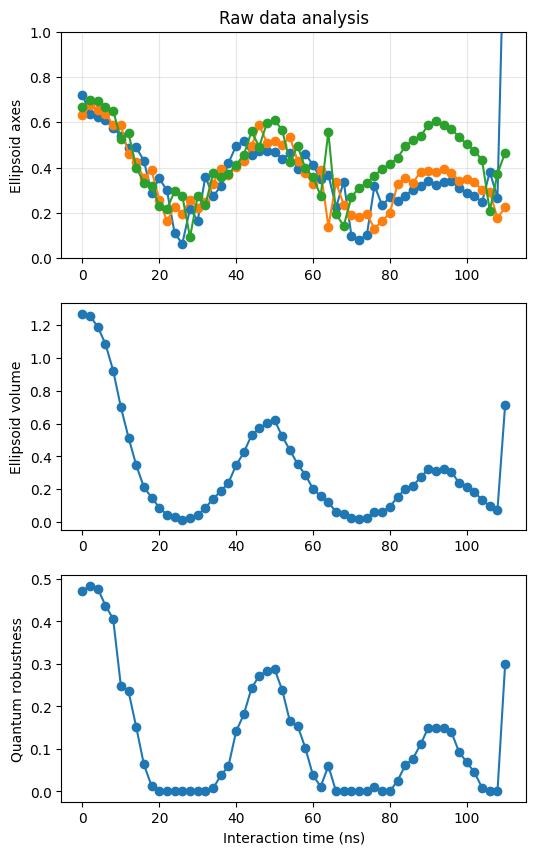

In [10]:
axes_list = np.array([non_Markovian_data_raw[key]['ellipsoid']['axes'] for key in non_Markovian_key])
volume_list = np.array([non_Markovian_data_raw[key]['ellipsoid']['volume'] for key in non_Markovian_key])
robustness_list = [non_Markovian_data_raw[key]['quantum_information']['robustness'] for key in non_Markovian_key]
fig = plt.figure(figsize=(6, 10))
ax_name = ['axes', 'volume', 'QM']
ax_axes = fig.add_subplot(len(ax_name), 1, 1)
fitted_axes = np.zeros_like(axes_list)
ax_volume = fig.add_subplot(len(ax_name), 1, 2)
ax_QM = fig.add_subplot(len(ax_name), 1, 3)
ax_axes.plot(interaction_time, axes_list[:,0], marker='o', label='axis x')
ax_axes.plot(interaction_time, axes_list[:,1], marker='o', label='axis y')
ax_axes.plot(interaction_time, axes_list[:,2], marker='o', label='axis z')
ax_axes.set_ylim(0,1)
ax_axes.set_ylabel('Ellipsoid axes')
ax_axes.grid(alpha=0.3)
ax_axes.set_title('Raw data analysis')
ax_volume.plot(interaction_time, volume_list, marker='o')
ax_volume.set_ylabel('Ellipsoid volume')
ax_QM.plot(interaction_time, robustness_list, marker='o')
ax_QM.set_xlabel('Interaction time (ns)')
ax_QM.set_ylabel('Quantum robustness')
plt.show()


In [11]:
non_Markovian_data['raw'] = non_Markovian_data_raw

### Simulation with readout error

In [28]:
from quam_libs.macros import generate_uniform_sphere_angles
swap_time = np.arange(0, 111e-9,2e-9)  # time in seconds

n_points =1000
error_rate = 0.16
t1 = 1.5e-6
t2= 0.14e-6

data_angle_list = []
theta_range, phi_range = generate_uniform_sphere_angles(n_points)
for i in range(len(swap_time)):
    data_angle = []
    for j in range(len(theta_range)):
        data_angle.append([theta_range[j], phi_range[j]])
    data_angle_list.append(np.array(data_angle))


simulation_data = {
    f"swap={int(swap_time[i]*1e9)}ns": {'data_angle':data_angle_list[i].tolist(),'data_xyz': []}
    for i in range(len(swap_time))
}

In [29]:
from quam_libs.nonMarkovian_simulation import BR_swap_dm, wait_dm,error_gate
from quam_libs.QI_utils import bloch_vector_to_density_matrix,density_matrix_to_bloch_vector

# xyz_data ={}
# bloch_vector_list = []
for i in range(n_points):
    theta, phi = data_angle_list[0][i]
    #dm = BR_swap_dm(theta, phi, tlist=swap_time)
    delay_dm = wait_dm(theta, phi,T1=t1,T2=t2)[-1]
    dm = BR_swap_dm(delay_dm,g=41.5e6/2*np.pi,T2=t2, T1=t1,tlist=swap_time)
    for j in range(len(swap_time)):
        dm_j = dm[j].ptrace(1)
        dm_j = error_gate(dm_j, error_rate).full()
        bloch_vector = density_matrix_to_bloch_vector(dm_j)
        simulation_data[f"swap={int(swap_time[j]*1e9)}ns"]['data_xyz'].append(bloch_vector.tolist())


/Users/jackchao/Desktop/Project/publication/quantum_memory/data_availability/quantum_memory_data/.venv/lib/python3.12/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [30]:
from quam_libs.quantum_memory.legacy.NoiseAnalyze import NoiseAnalyze, EllipsoidFitParameter  
ellipsoid_fit_parameters = EllipsoidFitParameter()

sim_swap_data = {}
sim_swap_analyze={}
do_convex_hull = True
for i, key in enumerate(simulation_data):
    data_xyz = simulation_data[key]['data_xyz']
    data_angle = simulation_data[key]['data_angle']
    data_dm = np.array([bloch_vector_to_density_matrix(data_xyz[i]) for i in range(len(data_xyz))])
    sim_swap_analyzer = NoiseAnalyze(data_xyz,data_angle,ellipsoid_fit_parameters)
    corrected_dm = sim_swap_analyzer.corrected_dm
    corrected_bloch = sim_swap_analyzer.corrected_bloch

    sim_swap_data[key] = {
        'data_xyz': data_xyz,
        'data_dm' :data_dm,
        'data_angle': data_angle,
        'corrected_xyz': corrected_bloch,
        'corrected_dm': corrected_dm,}
    sim_swap_analyze[key] = sim_swap_analyzer

In [31]:
from quam_libs.quantum_memory.legacy.NoiseAnalyze import QuantumMemory

swap_result_dict ={}
for key in sim_swap_data.keys():
    center, axes, R, volume, param = sim_swap_analyze[key].ellipsoid_fit()
    qm_analyze = QuantumMemory(axes,center,R)
    choi_state = qm_analyze.choi_state()
    swap_result_dict[key] ={
        'axes': axes,
        'center': center,
        'R': R,
        'param': param,
        'volume': volume,
        'choi state': choi_state,
        'memory robustness': qm_analyze.memory_robustness,
    }

In [32]:
def perm_order(axes,center,R_test,method='rotation'):
    """
    method axes: it use the axes to determine the order of the rotation matrix, the max axes should be z-axis
    method rotation: it use the rotation matrix to determine the order of the rotation matrix, it order the 
    rotation matrix by the maximum absolute value of each row, and then sort the rows based on the order    
    """
    if method == 'rotation':
        perm0 = np.argmax(np.abs(R_test[0]))
        perm1 = np.argmax(np.abs(R_test[1]))
        perm2 = np.argmax(np.abs(R_test[2]))
        perm = np.array([perm0, perm1, perm2])
        idx = np.argsort(perm)
    elif method == 'axes':
        z_min = np.argmin(np.abs(axes))
        if z_min == 0:
            idx = np.array([2,1,0])
        elif z_min == 1:
            idx = np.array([0,2,1])
        elif z_min == 2:
            idx = np.array([0,1,2])
    R_test = R_test[idx, :]
    axes = axes[idx]
    center = center[idx]
    if np.linalg.det(R_test) >0:
        pass
    elif np.linalg.det(R_test) < 0:
        R_test[0] *= -1  
    else:
        print(f"R_test is not a valid rotation matrix, det(R_test)={np.linalg.det(R_test)}")
        raise ValueError("R_test is not a valid rotation matrix")
    return axes,center,R_test,idx


keys= sim_swap_data.keys()
for key in keys:
    print(f"Results for {key}:")
    R = swap_result_dict[key]['R']
    center = swap_result_dict[key]['center']
    axes = swap_result_dict[key]['axes']
    print(f"R:\n{R}")
    print(f"Center:\n{center}")
    print(f"Axes:\n{axes}")
    print(f"choi state:\n{swap_result_dict[key]['choi state']}")
    print('-'*75)
    axes, center_,R,perm = perm_order(axes,center,R,method='rotation')
    print("After swapping the axes, center and R")
    print(f"R:\n{R}")
    print(f"Center:\n{center}")
    print(f"Axes:\n{axes}")
    choi = QuantumMemory(axes,center,R).choi_state()
    print(f"choi state:\n{choi}")
    print('-'*100)

    swap_result_dict[key]['R'] = R
    swap_result_dict[key]['axes'] = axes
    swap_result_dict[key]['center'] = center
    swap_result_dict[key]['choi state'] = choi

Results for swap=0ns:
R:
[[ 1.     0.015  0.   ]
 [ 0.     1.    -0.   ]
 [-0.     0.     1.   ]]
Center:
[-0.  0.  0.]
Axes:
[0.84 0.84 0.68]
choi state:
[[ 0.42+0.j    -0.  -0.j    -0.  +0.j     0.42+0.j   ]
 [-0.  +0.j     0.08+0.j    -0.  +0.003j -0.  +0.j   ]
 [-0.  -0.j    -0.  -0.003j  0.08+0.j    -0.  -0.j   ]
 [ 0.42+0.j    -0.  -0.j    -0.  +0.j     0.42+0.j   ]]
---------------------------------------------------------------------------
After swapping the axes, center and R
R:
[[ 1.     0.015  0.   ]
 [ 0.     1.    -0.   ]
 [-0.     0.     1.   ]]
Center:
[-0.  0.  0.]
Axes:
[0.84 0.84 0.68]
choi state:
[[ 0.42+0.j    -0.  -0.j    -0.  +0.j     0.42+0.j   ]
 [-0.  +0.j     0.08+0.j    -0.  +0.003j -0.  +0.j   ]
 [-0.  -0.j    -0.  -0.003j  0.08+0.j    -0.  -0.j   ]
 [ 0.42+0.j    -0.  -0.j    -0.  +0.j     0.42+0.j   ]]
----------------------------------------------------------------------------------------------------
Results for swap=2ns:
R:
[[ 0.     0.     1.   ]
 [-0.9

In [33]:
from quam_libs.quantum_memory.legacy.marcos import diagnose_choi_states
tol = 1e-6
swap_choi_list = [swap_result_dict[key]["choi state"] for key in swap_result_dict.keys()]
keys = list(swap_result_dict.keys())
df = diagnose_choi_states(swap_choi_list,keys,tol_pos=tol, tol_tp=tol)

In [34]:
from quam_libs.quantum_memory.legacy.NoiseAnalyze import Checker
np.set_printoptions(precision=3, suppress=True)
for i,key in enumerate(swap_result_dict.keys()):
    checker = Checker(swap_choi_list[i])
    choi, count = checker.choi_checker(index=[1], repeat=100, tol=tol, print_reason=False)
    print(f"After {count} iterations, the Choi state is:\n{choi}")
    print('-'*100)
    swap_result_dict[key]["choi state"] = choi

After 5 iterations, the Choi state is valid.
After 5 iterations, the Choi state is:
[[ 0.42+0.j    -0.  +0.j    -0.  +0.j     0.42-0.j   ]
 [-0.  -0.j     0.08+0.j    -0.  +0.003j  0.  -0.j   ]
 [-0.  -0.j    -0.  -0.003j  0.08+0.j    -0.  +0.j   ]
 [ 0.42+0.j     0.  +0.j    -0.  -0.j     0.42+0.j   ]]
----------------------------------------------------------------------------------------------------
After 2 iterations, the Choi state is valid.
After 2 iterations, the Choi state is:
[[ 0.42 +0.j  0.   -0.j  0.   +0.j -0.387+0.j]
 [ 0.   +0.j  0.08 +0.j  0.   +0.j -0.   -0.j]
 [ 0.   -0.j  0.   -0.j  0.086+0.j -0.   +0.j]
 [-0.387-0.j -0.   +0.j -0.   -0.j  0.414+0.j]]
----------------------------------------------------------------------------------------------------
After 2 iterations, the Choi state is valid.
After 2 iterations, the Choi state is:
[[ 0.103+0.j     0.   -0.j     0.   +0.j    -0.   -0.j   ]
 [ 0.   +0.j     0.397+0.j    -0.335+0.186j -0.   -0.j   ]
 [ 0.   -0.j    -0

In [35]:
swap_choi_list = [swap_result_dict[key]["choi state"] for key in swap_result_dict.keys()]
keys = list(swap_result_dict.keys())
df = diagnose_choi_states(swap_choi_list,keys,tol_pos=tol, tol_tp=tol)

In [36]:
from quam_libs.quantum_memory.entanglement_robustness import entanglementRobustness
for i,key in enumerate(swap_result_dict.keys()):
    swap_result_dict[key]['memory robustness'] = entanglementRobustness(swap_result_dict[key]["choi state"])

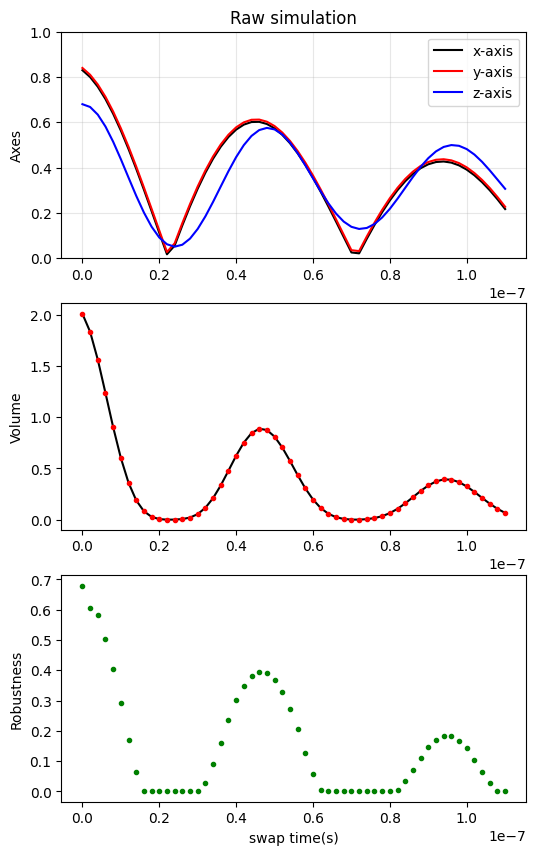

In [37]:
axes_list = np.array([swap_result_dict[key]['axes'] for key in sim_swap_analyze.keys()])
volume_list = np.array([swap_result_dict[key]['volume'] for key in sim_swap_analyze.keys()])
center_list = np.array([swap_result_dict[key]['center'] for key in sim_swap_analyze.keys()])
robustness_list = np.array([swap_result_dict[key]['memory robustness'] for key in sim_swap_analyze.keys()])

fig = plt.figure(figsize=(6, 10))
ax_name = ['axes', 'volume', 'QM']
ax_axes = fig.add_subplot(len(ax_name), 1, 1)
ax_volume = fig.add_subplot(len(ax_name), 1, 2)
ax_QM = fig.add_subplot(len(ax_name), 1, 3)
ax_axes.set_title('Raw simulation')
ax_axes.plot(swap_time,axes_list[:, 0]-0.01,'k' ,label='x-axis')
ax_axes.plot(swap_time,axes_list[:, 1],'r',label='y-axis')
ax_axes.plot(swap_time,axes_list[:, 2],'b', label='z-axis')
ax_axes.set_ylim(0, 1)  # Adjust the y-axis limits to focus on the axes values
ax_axes.legend()
ax_axes.grid(alpha=0.3)
ax_axes.set_ylabel('Axes')
ax_volume.plot(swap_time,volume_list,'k', label='volume')
ax_volume.plot(swap_time,volume_list,'.r', label='volume')
#ax_volume.set_ylim(3.5,4.5)
ax_volume.set_ylabel('Volume')
ax_QM.plot(swap_time,robustness_list,'.g',label='memory robustness')
ax_QM.set_ylabel('Robustness')
ax_QM.set_xlabel('swap time(s)')
plt.show()

In [39]:
non_Markovian_data['sim_raw'] = {key:{
    'data':sim_swap_data[key],
    'ellipsoid':{
        'axes': swap_result_dict[key]['axes'],
        'center': swap_result_dict[key]['center'],
        'R': swap_result_dict[key]['R'],
        'volume': swap_result_dict[key]['volume'],
        'param': swap_result_dict[key]['param']},
    'quantum_information':{
        'choi': swap_result_dict[key]['choi state'],
        'robustness': swap_result_dict[key]['memory robustness']
    }
} for key in sim_swap_data.keys()}

### Plot togather

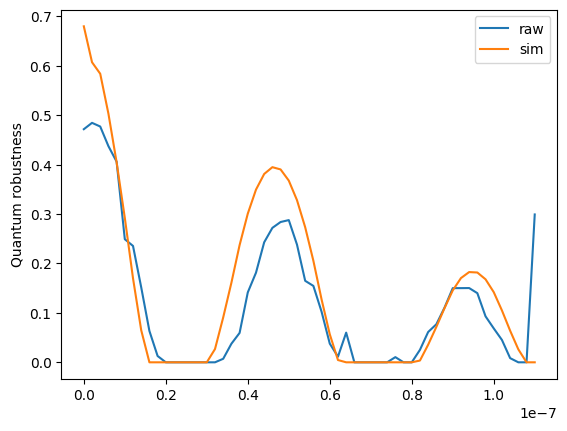

In [45]:
raw_robustness_list = [non_Markovian_data['raw'][key]['quantum_information']['robustness'] for key in non_Markovian_data['raw'].keys()]
sim_robustness_list = [non_Markovian_data['sim_raw'][key]['quantum_information']['robustness']  for key in non_Markovian_data['sim_raw'].keys()]

plt.plot(interaction_time*1e-9,raw_robustness_list,label = 'raw')
plt.plot(swap_time,sim_robustness_list,label='sim')
plt.ylabel('Quantum robustness')
plt.legend()
plt.show()


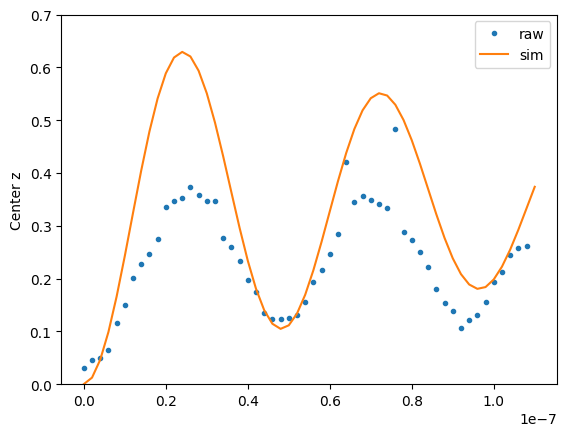

In [44]:
raw_center_list = np.array( [non_Markovian_data['raw'][key]['ellipsoid']['center'] for key in non_Markovian_data['raw'].keys()])
sim_center_list = np.array( [non_Markovian_data['sim_raw'][key]['ellipsoid']['center'] for key in non_Markovian_data['sim_raw'].keys()])

plt.plot(interaction_time*1e-9,raw_center_list[:,2],'.',label = 'raw')
plt.plot(swap_time,sim_center_list[:,2],label='sim')
plt.ylabel('Center z')
plt.ylim(0,0.7)
plt.legend()
plt.show()

## MLE

### Experimental

In [46]:
from quam_libs.quantum_memory.legacy.marcos import MLE
node_qm = node.load_from_id(1763,base_path=data_path)
conf_mat = node_qm.results['results']['q0']['confusion_matrix']
swap_time = np.arange(0,111,2)
non_Markovian_data_mle = {}
non_Markovian_analyze_mle = {}

for i,key in enumerate(list(non_Markovian_data['raw'].keys())):

    x = non_Markovian_data['raw'][key]['data']['original_xyz'][:,0]
    y = non_Markovian_data['raw'][key]['data']['original_xyz'][:,1]
    z = non_Markovian_data['raw'][key]['data']['original_xyz'][:,2]
    px, py, pz = (1-x)/2, (1-y)/2, (1-z)/2

    new_px_0 = np.array([MLE([1-px[j],px[j]],conf_mat)[0] for j in range(len(px))])
    new_py_0 = np.array([MLE([1-py[j],py[j]],conf_mat)[0] for j in range(len(py))])
    new_pz_0 = np.array([MLE([1-pz[j],pz[j]],conf_mat)[0] for j in range(len(pz))])
    
    MLE_data_xyz = np.array([2*new_px_0-1,2*new_py_0-1,2*new_pz_0-1]).T
    data_angle = non_Markovian_data['raw'][key]['data']['angle']
    data_dm = np.array([bloch_vector_to_density_matrix(MLE_data_xyz[i]) for i in range(len(MLE_data_xyz))])

    noise_analyzer = QuantumMemoryAnalyze(MLE_data_xyz,data_angle)
    corrected_dm = noise_analyzer.corrected_dm
    corrected_bloch = noise_analyzer.corrected_bloch
    ellipsoid_results = noise_analyzer.ellipsoid_fit_results()
    # Get choi state from the property
    choi_state = noise_analyzer.choi
    # Compute robustness using the static method
    robustness_value = QuantumMemoryAnalyze.memory_robustness(choi_state)
    non_Markovian_data_mle[key] = {
        'data':{
            'original_xyz': MLE_data_xyz,
            'original_dm' :data_dm,
            'angle': data_angle,
            'corrected_xyz': corrected_bloch,
            'corrected_dm': corrected_dm
        },
        'ellipsoid':{
            'axes':ellipsoid_results['axes'],
            'center':ellipsoid_results['center'],
            'volume':ellipsoid_results['volume'],
            'param':ellipsoid_results['fit_param'],
            "rotation_matrix":ellipsoid_results['rotation_matrix'],
        },
        "quantum_information":{
            "choi":choi_state,
            "robustness":robustness_value
        }
    }
    non_Markovian_analyze_mle[key] = noise_analyzer


In [47]:
from quam_libs.quantum_memory.legacy.NoiseAnalyze import Checker, QuantumMemory

def qm_value(axes,center,R):
    qm_analyze = QuantumMemory(axes,center,R)
    choi_state = qm_analyze.choi_state()
    checker = Checker(choi_state)
    choi, count = checker.choi_checker(index=[1], repeat=100, print_reason=False)
    return QuantumMemory.memory_robustness(choi)

In [48]:
from quam_libs.ellipsoid_utils.swap_axes_R_macros import align_max_axis_to_z
R_corrected1_list, axes_corrected1_list, qmr_maximum_z_1_list = [],[],[]

for key in non_Markovian_key:
    R = non_Markovian_data_mle[key]['ellipsoid']['rotation_matrix']
    axes = non_Markovian_data_mle[key]['ellipsoid']['axes']
    center = non_Markovian_data_mle[key]['ellipsoid']['center']
    R_corrected,axes_corrected = align_max_axis_to_z(R, axes)
    if np.linalg.det(R_corrected)<0:
        R_max = R_corrected.copy()
        qmr = qm_value(axes_corrected, center, R_corrected)
        for j in range(3):
            R_copy = R_corrected.copy()
            R_copy[:,j] *= -1
            qmr_value = qm_value(axes_corrected, center, R_copy)
            if qmr_value > qmr:
                R_max = R_copy.copy()
                qmr = qmr_value
    non_Markovian_data_mle[key]['ellipsoid']['rotation_matrix'] = R_max
    non_Markovian_data_mle[key]['ellipsoid']['axes'] = axes_corrected
    non_Markovian_data_mle[key]['quantum_information']['robustness'] = qmr

After 7 iterations, the Choi state is valid.
Choi state is invalid:
❌ Choi state is not positive semi-definite. Eigenvalues: [-0.     0.019  0.032  0.948]
After 3 iterations, the Choi state is valid.
After 4 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 3 iterations, the Choi state is valid.
Choi state is invalid:
❌ Choi state is not positive semi-definite. Eigenvalues: [-0.     0.018  0.054  0.928]
Choi state is invalid:
❌ Choi state is not positive semi-definite. Eigenvalues: [-0.     0.017  0.068  0.915]
After 2 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 3 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 7 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 3 iterations, the Choi state is valid.
Choi state is invalid:
❌ Trace of the Choi state is not 1. Got trace = (0.99999998771

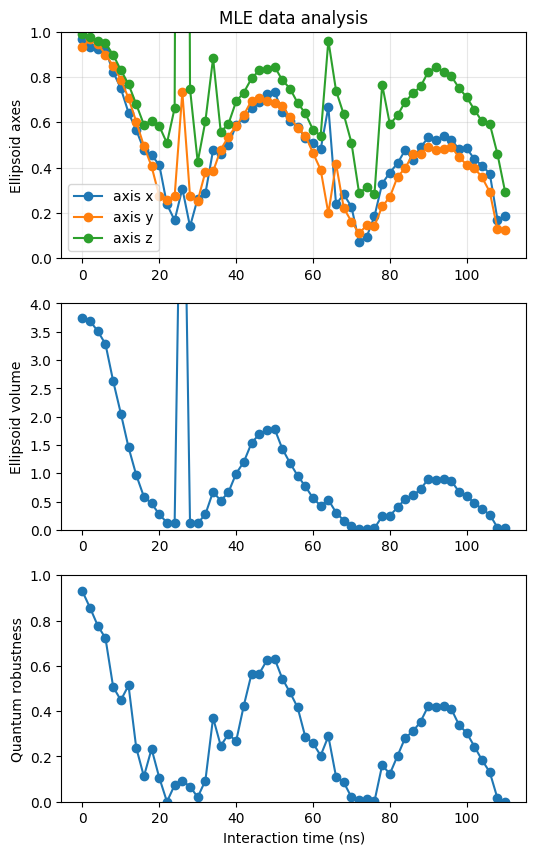

In [65]:
axes_list = np.array([non_Markovian_data_mle[key]['ellipsoid']['axes'] for key in non_Markovian_key])
volume_list = np.array([non_Markovian_data_mle[key]['ellipsoid']['volume'] for key in non_Markovian_key])
robustness_list = [non_Markovian_data_mle[key]['quantum_information']['robustness'] for key in non_Markovian_key]
fig = plt.figure(figsize=(6, 10))
ax_name = ['axes', 'volume', 'QM']
ax_axes = fig.add_subplot(len(ax_name), 1, 1)
fitted_axes = np.zeros_like(axes_list)
ax_volume = fig.add_subplot(len(ax_name), 1, 2)
ax_QM = fig.add_subplot(len(ax_name), 1, 3)
ax_axes.plot(interaction_time, axes_list[:,0], marker='o', label='axis x')
ax_axes.plot(interaction_time, axes_list[:,1], marker='o', label='axis y')
ax_axes.plot(interaction_time, axes_list[:,2], marker='o', label='axis z')
ax_axes.legend()
ax_axes.set_ylim(0,1)
ax_axes.set_ylabel('Ellipsoid axes')
ax_axes.grid(alpha=0.3)
ax_axes.set_title('MLE data analysis')
ax_volume.plot(interaction_time, volume_list, marker='o')
ax_volume.set_ylabel('Ellipsoid volume')
ax_volume.set_ylim(0,4)
ax_QM.set_ylim(0,1)
ax_QM.plot(interaction_time, robustness_list, marker='o')
ax_QM.set_xlabel('Interaction time (ns)')
ax_QM.set_ylabel('Quantum robustness')
plt.show()


In [50]:
non_Markovian_data['mle'] = non_Markovian_data_mle

### Simulation

In [67]:
from quam_libs.macros import generate_uniform_sphere_angles
swap_time = np.arange(0, 111e-9,2e-9)  # time in seconds

n_points =1000
error_rate = 0
t1 = 1.5e-6
t2= 0.25e-6

data_angle_list = []
theta_range, phi_range = generate_uniform_sphere_angles(n_points)
for i in range(len(swap_time)):
    data_angle = []
    for j in range(len(theta_range)):
        data_angle.append([theta_range[j], phi_range[j]])
    data_angle_list.append(np.array(data_angle))


simulation_data = {
    f"swap={int(swap_time[i]*1e9)}ns": {'data_angle':data_angle_list[i].tolist(),'data_xyz': []}
    for i in range(len(swap_time))
}

In [68]:
from quam_libs.nonMarkovian_simulation import BR_swap_dm, wait_dm,error_gate
from quam_libs.QI_utils import bloch_vector_to_density_matrix,density_matrix_to_bloch_vector

# xyz_data ={}
# bloch_vector_list = []
for i in range(n_points):
    theta, phi = data_angle_list[0][i]
    #dm = BR_swap_dm(theta, phi, tlist=swap_time)
    delay_dm = wait_dm(theta, phi,T1=t1,T2=t2)[-1]
    dm = BR_swap_dm(delay_dm,g=41.5e6/2*np.pi,T2=t2, T1=t1,tlist=swap_time)
    for j in range(len(swap_time)):
        dm_j = dm[j].ptrace(1)
        dm_j = error_gate(dm_j, error_rate).full()
        bloch_vector = density_matrix_to_bloch_vector(dm_j)
        simulation_data[f"swap={int(swap_time[j]*1e9)}ns"]['data_xyz'].append(bloch_vector.tolist())


/Users/jackchao/Desktop/Project/publication/quantum_memory/data_availability/quantum_memory_data/.venv/lib/python3.12/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [69]:
from quam_libs.quantum_memory.legacy.NoiseAnalyze import NoiseAnalyze, EllipsoidFitParameter  
ellipsoid_fit_parameters = EllipsoidFitParameter()

sim_swap_data = {}
sim_swap_analyze={}
do_convex_hull = True
for i, key in enumerate(simulation_data):
    data_xyz = simulation_data[key]['data_xyz']
    data_angle = simulation_data[key]['data_angle']
    data_dm = np.array([bloch_vector_to_density_matrix(data_xyz[i]) for i in range(len(data_xyz))])
    sim_swap_analyzer = NoiseAnalyze(data_xyz,data_angle,ellipsoid_fit_parameters)
    corrected_dm = sim_swap_analyzer.corrected_dm
    corrected_bloch = sim_swap_analyzer.corrected_bloch

    sim_swap_data[key] = {
        'data_xyz': data_xyz,
        'data_dm' :data_dm,
        'data_angle': data_angle,
        'corrected_xyz': corrected_bloch,
        'corrected_dm': corrected_dm,}
    sim_swap_analyze[key] = sim_swap_analyzer

In [70]:
from quam_libs.quantum_memory.legacy.NoiseAnalyze import QuantumMemory

swap_result_dict ={}
for key in sim_swap_data.keys():
    center, axes, R, volume, param = sim_swap_analyze[key].ellipsoid_fit()
    qm_analyze = QuantumMemory(axes,center,R)
    choi_state = qm_analyze.choi_state()
    swap_result_dict[key] ={
        'axes': axes,
        'center': center,
        'R': R,
        'param': param,
        'volume': volume,
        'choi state': choi_state,
        'memory robustness': qm_analyze.memory_robustness,
    }

In [71]:
def perm_order(axes,center,R_test,method='rotation'):
    """
    method axes: it use the axes to determine the order of the rotation matrix, the max axes should be z-axis
    method rotation: it use the rotation matrix to determine the order of the rotation matrix, it order the 
    rotation matrix by the maximum absolute value of each row, and then sort the rows based on the order    
    """
    if method == 'rotation':
        perm0 = np.argmax(np.abs(R_test[0]))
        perm1 = np.argmax(np.abs(R_test[1]))
        perm2 = np.argmax(np.abs(R_test[2]))
        perm = np.array([perm0, perm1, perm2])
        idx = np.argsort(perm)
    elif method == 'axes':
        z_min = np.argmin(np.abs(axes))
        if z_min == 0:
            idx = np.array([2,1,0])
        elif z_min == 1:
            idx = np.array([0,2,1])
        elif z_min == 2:
            idx = np.array([0,1,2])
    R_test = R_test[idx, :]
    axes = axes[idx]
    center = center[idx]
    if np.linalg.det(R_test) >0:
        pass
    elif np.linalg.det(R_test) < 0:
        R_test[0] *= -1  
    else:
        print(f"R_test is not a valid rotation matrix, det(R_test)={np.linalg.det(R_test)}")
        raise ValueError("R_test is not a valid rotation matrix")
    return axes,center,R_test,idx


keys= sim_swap_data.keys()
for key in keys:
    print(f"Results for {key}:")
    R = swap_result_dict[key]['R']
    center = swap_result_dict[key]['center']
    axes = swap_result_dict[key]['axes']
    print(f"R:\n{R}")
    print(f"Center:\n{center}")
    print(f"Axes:\n{axes}")
    print(f"choi state:\n{swap_result_dict[key]['choi state']}")
    print('-'*75)
    axes, center_,R,perm = perm_order(axes,center,R,method='rotation')
    print("After swapping the axes, center and R")
    print(f"R:\n{R}")
    print(f"Center:\n{center}")
    print(f"Axes:\n{axes}")
    choi = QuantumMemory(axes,center,R).choi_state()
    print(f"choi state:\n{choi}")
    print('-'*100)

    swap_result_dict[key]['R'] = R
    swap_result_dict[key]['axes'] = axes
    swap_result_dict[key]['center'] = center
    swap_result_dict[key]['choi state'] = choi

Results for swap=0ns:
R:
[[ 1.     0.001  0.003]
 [ 0.    -0.05  -0.999]
 [ 0.     0.999 -0.044]]
Center:
[-0.  0. -0.]
Axes:
[1. 1. 1.]
choi state:
[[ 0.239+0.j  0.   -0.j  0.   +0.j  0.238+0.j]
 [ 0.   +0.j  0.261+0.j  0.262+0.j -0.   -0.j]
 [ 0.   -0.j  0.262-0.j  0.261+0.j -0.   +0.j]
 [ 0.238+0.j -0.   +0.j -0.   -0.j  0.239+0.j]]
---------------------------------------------------------------------------
After swapping the axes, center and R
R:
[[-1.    -0.001 -0.003]
 [ 0.     0.999 -0.044]
 [ 0.    -0.05  -0.999]]
Center:
[-0.  0. -0.]
Axes:
[1. 1. 1.]
choi state:
[[ 0. +0.j    -0. +0.012j -0. -0.012j -0. +0.j   ]
 [-0. -0.012j  0.5+0.j    -0.5-0.j     0. +0.012j]
 [-0. +0.012j -0.5+0.j     0.5+0.j     0. -0.012j]
 [-0. +0.j     0. -0.012j  0. +0.012j  0. +0.j   ]]
----------------------------------------------------------------------------------------------------
Results for swap=2ns:
R:
[[ 0.     0.    -1.   ]
 [ 0.978 -0.209  0.   ]
 [-0.209 -0.978 -0.   ]]
Center:
[0.    0.

In [72]:
from quam_libs.quantum_memory.legacy.marcos import diagnose_choi_states
tol = 1e-6
swap_choi_list = [swap_result_dict[key]["choi state"] for key in swap_result_dict.keys()]
keys = list(swap_result_dict.keys())
df = diagnose_choi_states(swap_choi_list,keys,tol_pos=tol, tol_tp=tol)

In [73]:
from quam_libs.quantum_memory.legacy.NoiseAnalyze import Checker
np.set_printoptions(precision=3, suppress=True)
for i,key in enumerate(swap_result_dict.keys()):
    checker = Checker(swap_choi_list[i])
    choi, count = checker.choi_checker(index=[1], repeat=100, tol=tol, print_reason=False)
    print(f"After {count} iterations, the Choi state is:\n{choi}")
    print('-'*100)
    swap_result_dict[key]["choi state"] = choi

After 4 iterations, the Choi state is valid.
After 4 iterations, the Choi state is:
[[ 0.   +0.j    -0.   +0.012j -0.   -0.012j -0.   +0.j   ]
 [-0.   -0.012j  0.5  +0.j    -0.499-0.j     0.   +0.012j]
 [-0.   +0.012j -0.499+0.j     0.5  +0.j     0.   -0.012j]
 [-0.   -0.j     0.   -0.012j  0.   +0.012j  0.   +0.j   ]]
----------------------------------------------------------------------------------------------------
After 2 iterations, the Choi state is valid.
After 2 iterations, the Choi state is:
[[ 0.009+0.j     0.   +0.j     0.   -0.j     0.   +0.j   ]
 [ 0.   -0.j     0.491+0.j     0.477-0.102j -0.   +0.j   ]
 [ 0.   +0.j     0.477+0.102j  0.5  +0.j    -0.   -0.j   ]
 [ 0.   -0.j    -0.   -0.j    -0.   +0.j     0.   +0.j   ]]
----------------------------------------------------------------------------------------------------
After 2 iterations, the Choi state is valid.
After 2 iterations, the Choi state is:
[[ 0.034+0.j     0.   -0.j     0.   +0.j    -0.   +0.j   ]
 [ 0.   +0.j 

In [74]:
swap_choi_list = [swap_result_dict[key]["choi state"] for key in swap_result_dict.keys()]
keys = list(swap_result_dict.keys())
df = diagnose_choi_states(swap_choi_list,keys,tol_pos=tol, tol_tp=tol)

In [75]:
from quam_libs.quantum_memory.entanglement_robustness import entanglementRobustness
for i,key in enumerate(swap_result_dict.keys()):
    swap_result_dict[key]['memory robustness'] = entanglementRobustness(swap_result_dict[key]["choi state"])

Text(0.5, 0, 'swap time(s)')

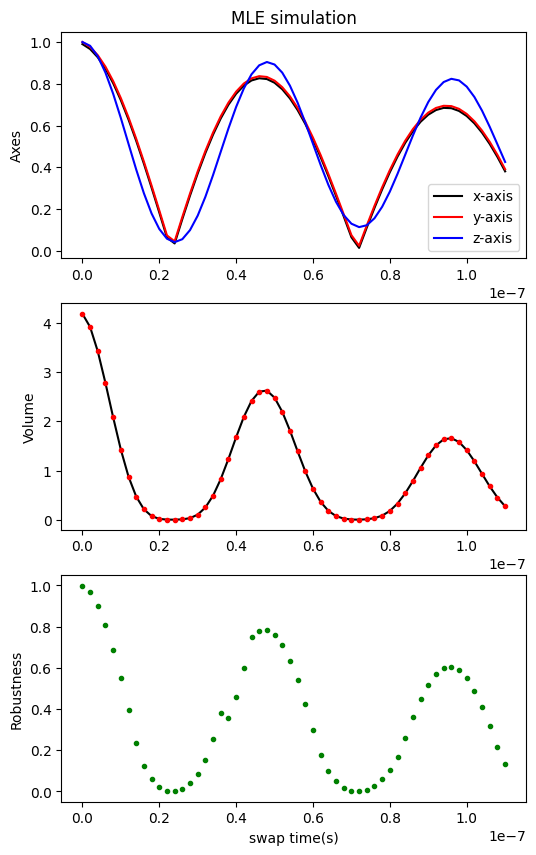

In [76]:
axes_list = np.array([swap_result_dict[key]['axes'] for key in sim_swap_analyze.keys()])
volume_list = np.array([swap_result_dict[key]['volume'] for key in sim_swap_analyze.keys()])
center_list = np.array([swap_result_dict[key]['center'] for key in sim_swap_analyze.keys()])
robustness_list = np.array([swap_result_dict[key]['memory robustness'] for key in sim_swap_analyze.keys()])

fig = plt.figure(figsize=(6, 10))
ax_name = ['axes', 'volume', 'QM']
ax_axes = fig.add_subplot(len(ax_name), 1, 1)
ax_volume = fig.add_subplot(len(ax_name), 1, 2)
ax_QM = fig.add_subplot(len(ax_name), 1, 3)
ax_axes.set_title('MLE simulation')
ax_axes.plot(swap_time,axes_list[:, 0]-0.01,'k' ,label='x-axis')
ax_axes.plot(swap_time,axes_list[:, 1],'r',label='y-axis')
ax_axes.plot(swap_time,axes_list[:, 2],'b', label='z-axis')
#ax_axes.set_ylim(0.9, 1.1)  # Adjust the y-axis limits to focus on the axes values
ax_axes.legend()
ax_axes.set_ylabel('Axes')
ax_volume.plot(swap_time,volume_list,'k', label='volume')
ax_volume.plot(swap_time,volume_list,'.r', label='volume')
#ax_volume.set_ylim(3.5,4.5)
ax_volume.set_ylabel('Volume')
ax_QM.plot(swap_time,robustness_list,'.g',label='memory robustness')
ax_QM.set_ylabel('Robustness')
ax_QM.set_xlabel('swap time(s)')


In [77]:
non_Markovian_data['sim_mle'] = {key:{
    'data':sim_swap_data[key],
    'ellipsoid':{
        'axes': swap_result_dict[key]['axes'],
        'center': swap_result_dict[key]['center'],
        'R': swap_result_dict[key]['R'],
        'volume': swap_result_dict[key]['volume'],
        'param': swap_result_dict[key]['param']},
    'quantum_information':{
        'choi': swap_result_dict[key]['choi state'],
        'robustness': swap_result_dict[key]['memory robustness']
    }
} for key in sim_swap_data.keys()}

### Plot togather

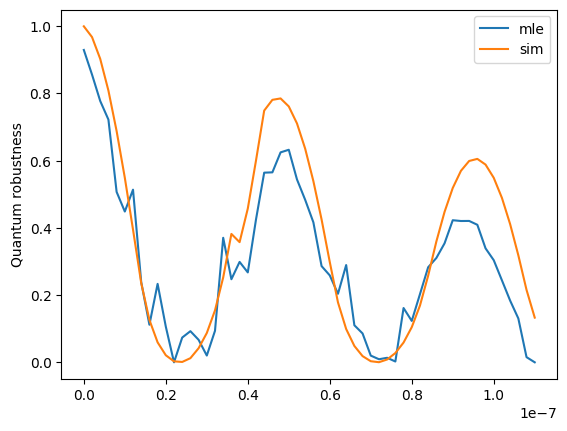

In [79]:
raw_robustness_list = [non_Markovian_data['mle'][key]['quantum_information']['robustness'] for key in non_Markovian_data['mle'].keys()]
sim_robustness_list = [non_Markovian_data['sim_mle'][key]['quantum_information']['robustness']  for key in non_Markovian_data['sim_mle'].keys()]

plt.plot(interaction_time*1e-9,raw_robustness_list,label = 'mle')
plt.plot(swap_time,sim_robustness_list,label='sim')
plt.ylabel('Quantum robustness')
plt.legend()
plt.show()

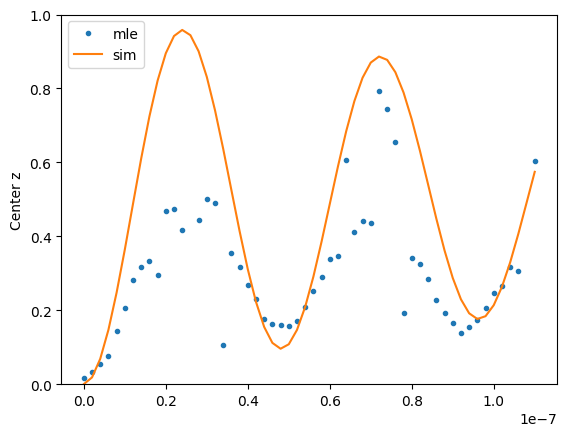

In [80]:
raw_center_list = np.array( [non_Markovian_data['mle'][key]['ellipsoid']['center'] for key in non_Markovian_data['mle'].keys()])
sim_center_list = np.array( [non_Markovian_data['sim_mle'][key]['ellipsoid']['center'] for key in non_Markovian_data['sim_mle'].keys()])

plt.plot(interaction_time*1e-9,raw_center_list[:,2],'.',label = 'mle')
plt.plot(swap_time,sim_center_list[:,2],label='sim')
plt.ylim(0,1)
plt.ylabel('Center z')
plt.legend()
plt.show()

# QPT

In [81]:
node  = QualibrationNode(name="quantum_memory_qpt")
experiment_index = np.arange(5203,5324,1)

qpt = {
    f'iswap_time={int(i)}ns': {
        'superoperator': node.load_from_id(experiment_index[i]).results['results']['q0']['superoperator'],
        'mitigated superoperator': node.load_from_id(experiment_index[i]).results['results']['q0']['mitigated superoperator'],
    }
    for i in range(len(experiment_index))
}

2026-03-02 01:46:52,474 - qualibrate - INFO - Creating node quantum_memory_qpt


In [82]:
def pauli_matrices():
    I = np.array([[1,0],[0,1]], dtype=complex)
    X = np.array([[0,1],[1,0]], dtype=complex)
    Y = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z = np.array([[1,0],[0,-1]], dtype=complex)
    return [I,X,Y,Z]

def vec_col(A): return A.reshape(-1, order='F')


def build_N_M(n=1):
    pals = pauli_matrices()
    N = np.column_stack([vec_col(P) for P in pals])
    M = np.vstack([vec_col(P).conj().T for P in pals])
    return N,M

def ptm_to_superop(R, n=1):
    N,M = build_N_M(n)
    return N @ R @ (M / (2**n))

def superop_to_choi(S, din, dout):
    S4 = S.reshape(dout,dout,din,din)
    L4 = np.transpose(S4, (0,2,1,3))
    return L4.reshape(din*dout, din*dout)

In [83]:
for i, key in enumerate(qpt.keys()):
    # Convert PTM to Choi state
    ptm = qpt[key]['superoperator']
    superop = ptm_to_superop(ptm)
    choi = superop_to_choi(superop, 2, 2) / 2
    
    # Apply Checker correction
    checker = Checker(choi)
    choi_corrected, count = checker.choi_checker(index=[1], repeat=100, tol=1e-8, print_reason=False)
    
    # Calculate robustness
    robustness_value = QuantumMemoryAnalyze.memory_robustness(choi_corrected)
    
    # Convert MLE PTM to Choi state
    mle_ptm = qpt[key]['mitigated superoperator']
    mle_superop = ptm_to_superop(mle_ptm)
    mle_choi = superop_to_choi(mle_superop, 2, 2) / 2
    
    # Apply Checker correction to MLE Choi
    checker = Checker(mle_choi)
    mle_choi_corrected, count = checker.choi_checker(index=[1], repeat=100, tol=1e-8, print_reason=False)
    
    # Calculate MLE robustness
    mle_robustness_value = QuantumMemoryAnalyze.memory_robustness(mle_choi_corrected)
    
    # Store results in qpt dictionary
    qpt[key]['choi'] = choi_corrected
    qpt[key]['robustness'] = robustness_value
    qpt[key]['mle choi'] = mle_choi_corrected
    qpt[key]['mle robustness'] = mle_robustness_value

After 2 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 3 iterations, the Choi state is valid.
After 7 iterations, the Choi state is valid.
After 3 iterations, the Choi state is valid.
After 8 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 11 iterations, the Choi state is valid.
After 2 iterations, the Choi state is valid.
After 10 iterations, the Choi state is valid.
After 3 iterations, the Choi state is valid.
Choi state is invalid:
❌ Choi state is not positive semi-definite. Eigenvalues: [-0.     0.011  0.132  0.857]
After 3 iterations, the Choi state is valid.
Choi state is invalid:
❌ Choi state is not positive semi-definite. Eigenvalues: [-0.     0.022  0.137  0.841]
After 3 iterations, the Choi state is valid.
Choi state is invalid:
❌ Choi state is not positive semi-definite. Eigenvalues: [-0.     0.017  0.145  0.838]
After 3 iterations, the Choi state is valid.
Choi state is invalid:
❌ Choi state is

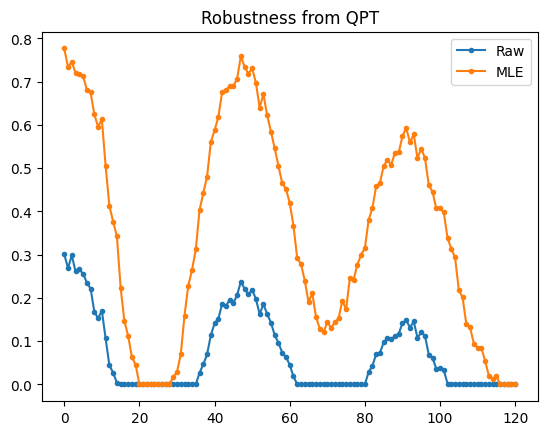

In [84]:
QPT_robustness_list = [qpt[key]['robustness'] for key in qpt.keys()]
QPT_mle_robustness_list = [qpt[key]['mle robustness'] for key in qpt.keys()]
plt.plot(QPT_robustness_list,'.-',label='Raw')
plt.plot(QPT_mle_robustness_list,'.-',label='MLE')
plt.title('Robustness from QPT')
plt.legend()
plt.show()

In [60]:
non_Markovian_data['qpt'] = qpt

## plot togather

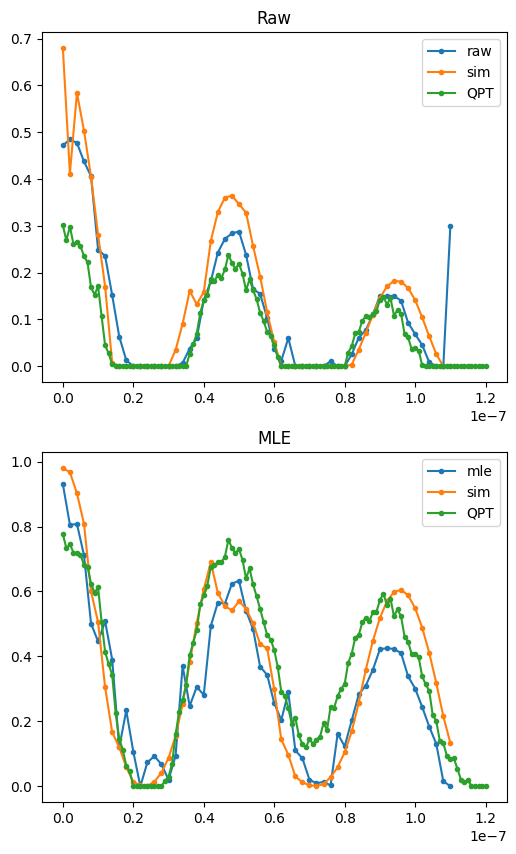

In [70]:
raw_QPT_robustness_list = [qpt[key]['robustness'] for key in qpt.keys()]
raw_ellipsoid_robustness_list = [non_Markovian_data['raw'][key]['quantum_information']['robustness'] for key in non_Markovian_data['raw'].keys()]
sim_ellipsoid_robustness_list = [non_Markovian_data['sim_raw'][key]['quantum_information']['robustness']  for key in non_Markovian_data['sim_raw'].keys()]
mle_QPT_robustness_list = [qpt[key]['mle robustness'] for key in qpt.keys()]
mle_ellipsoid_robustness_list = [non_Markovian_data['mle'][key]['quantum_information']['robustness'] for key in non_Markovian_data['mle'].keys()]
sim_mle_ellipsoid_robustness_list = [non_Markovian_data['sim_mle'][key]['quantum_information']['robustness']  for key in non_Markovian_data['sim_mle'].keys()]


time_QPT = np.arange(0, len(raw_QPT_robustness_list), 1)
time_ellipsoid = np.arange(0, len(raw_ellipsoid_robustness_list), 1)*2
fig = plt.figure(figsize=(6, 10))
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)
ax1.plot(time_ellipsoid*1e-9,raw_ellipsoid_robustness_list,'.-',label = 'raw')
ax1.plot(time_ellipsoid*1e-9,sim_ellipsoid_robustness_list,'.-',label='sim')
ax1.plot(time_QPT*1e-9,QPT_robustness_list,'.-',label='QPT')
ax1.legend()
ax1.set_title('Raw')
ax2.plot(time_ellipsoid*1e-9,mle_ellipsoid_robustness_list,'.-',label = 'mle')
ax2.plot(time_ellipsoid*1e-9,sim_mle_ellipsoid_robustness_list,'.-',label='sim')
ax2.plot(time_QPT*1e-9,mle_QPT_robustness_list,'.-',label='QPT')
ax2.legend()
ax2.set_title('MLE')
plt.show()